In [2]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# path
DATA_PROCESSED = Path(r'C:\dev\clinicaltrials-study\data\processed')
RESULTS_DIR = Path('../results/EDA1_outputs')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [4]:

# Utility: safe save figure
def savefig(path, tight=True, dpi=200, show=True):
    if tight:
        plt.tight_layout()
    plt.savefig(RESULTS_DIR / path, dpi=dpi)
    if show:
        plt.show()
    plt.close()

In [5]:
# 데이터셋 불러오기
df_EDA_1 = pd.read_csv(DATA_PROCESSED/'df_merged.csv')
print(df_EDA_1.shape)
print(df_EDA_1.duplicated().sum())

(278805, 81)
0


In [6]:
df_EDA_1.head()

,nct_id,study_type,enrollment,overall_status,number_of_arms,has_dmc,has_expanded_access,is_fda_regulated_drug,is_fda_regulated_device,duration_of_study,...,elig_age_child,elig_age_mixed,elig_age_senior,elig_age_unknown,sponsor_Goverment,sponsor_Industry,sponsor_Other,sponsor_Unknown,role_collaborator,role_lead
0,NCT00946062,INTERVENTIONAL,190.0,1,2.0,0,0,-1,-1,973,...,0,0,0,0,0,0,1,0,1,1
1,NCT06515847,INTERVENTIONAL,60.0,1,2.0,0,0,0,0,365,...,0,1,0,0,0,0,1,0,0,1
2,NCT03717220,INTERVENTIONAL,26.0,1,1.0,-1,0,0,0,2937,...,0,0,0,0,0,0,1,0,1,1
3,NCT03159455,INTERVENTIONAL,48.0,1,2.0,0,0,0,0,192,...,0,0,0,0,0,1,0,0,0,1
4,NCT00766675,INTERVENTIONAL,80.0,1,1.0,0,0,-1,-1,182,...,0,1,0,0,0,1,0,0,0,1


In [7]:
df_EDA_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 278805 entries, 0 to 278804
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   nct_id                               278805 non-null  str    
 1   study_type                           278805 non-null  str    
 2   enrollment                           278805 non-null  float64
 3   overall_status                       278805 non-null  int64  
 4   number_of_arms                       278805 non-null  float64
 5   has_dmc                              278805 non-null  int64  
 6   has_expanded_access                  278805 non-null  int64  
 7   is_fda_regulated_drug                278805 non-null  int64  
 8   is_fda_regulated_device              278805 non-null  int64  
 9   duration_of_study                    278805 non-null  int64  
 10  phase_1                              278805 non-null  int64  
 11  phase_2                 

In [8]:
print(df_EDA_1.isna().sum().sort_values(ascending=False).head(10))

nct_id                     0
study_type                 0
enrollment                 0
overall_status             0
number_of_arms             0
has_dmc                    0
has_expanded_access        0
is_fda_regulated_drug      0
is_fda_regulated_device    0
duration_of_study          0
dtype: int64


In [9]:
df_EDA_1.drop(columns = ['study_type'], inplace= True)

In [10]:
# Target distribution (table + plot)
print("Target Class Distribution:")
counts = df_EDA_1['overall_status'].value_counts(dropna=False)
perc = df_EDA_1['overall_status'].value_counts(normalize=True, dropna=False) * 100
target_table = pd.DataFrame({"count": counts, "percent": perc.round(2)})
display(target_table)

Target Class Distribution:


,count,percent
overall_status,,
1,238725,85.62
0,40080,14.38


- 1: completed
- 0: terminated, withdrawn

In [11]:
# Save table
target_table.to_csv(RESULTS_DIR / "target_distribution.csv")

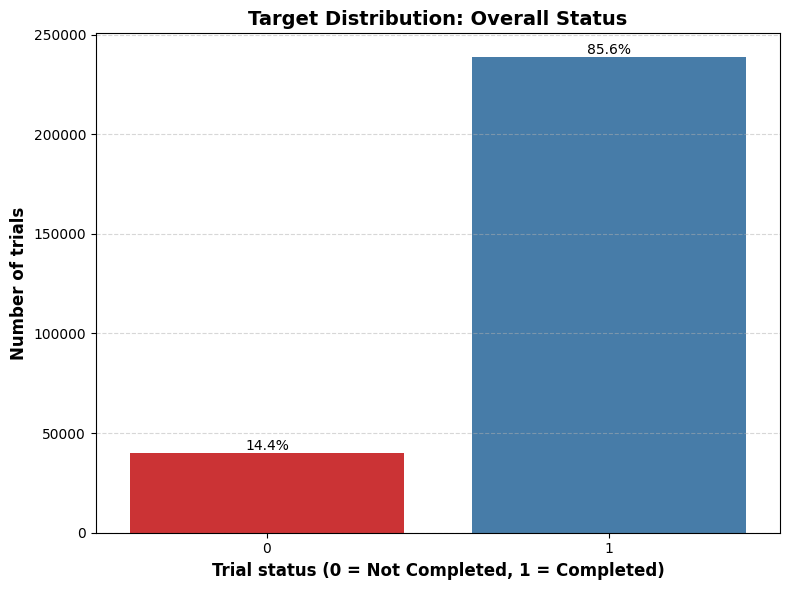

In [12]:
# Plot
plt.figure(figsize = (8, 6))
ax = sns.countplot(x = 'overall_status', hue = 'overall_status', data = df_EDA_1, palette = 'Set1', legend = False)
plt.title('Target Distribution: Overall Status', fontsize = 14, fontweight = 'bold')
plt.xlabel('Trial status (0 = Not Completed, 1 = Completed)', fontsize = 12, fontweight = 'bold')
plt.ylabel('Number of trials', fontsize = 12, fontweight = 'bold')

# Add percentage labels on bars
total = len(df_EDA_1)
for p in ax.patches:
    count = p.get_height()
    percentage = count / total * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width()/2, count),
                ha = 'center', va = 'bottom', fontsize = 10)
    
plt.grid(True, axis = 'y', linestyle="--", alpha = 0.5)
savefig("target_distribution.png")

In [13]:
# Numerical columns
# enrollment: 참가자수, duration_of_study: 연구기간, number_of_arms: 그룹수, intervention_count: 개입수
df_EDA_1[['enrollment', 'duration_of_study', 'number_of_arms', 'intervention_count']].describe()

,enrollment,duration_of_study,number_of_arms,intervention_count
count,2.788050e+05,278805.000000,278805.000000,278805.000000
mean,6.034725e+02,902.863830,2.184416,1.151163
std,4.720788e+04,876.985615,1.366113,0.418088
min,0.000000e+00,-24.000000,1.000000,1.000000
25%,2.300000e+01,304.000000,2.000000,1.000000
50%,5.200000e+01,658.000000,2.000000,1.000000
75%,1.260000e+02,1234.000000,2.000000,1.000000
max,2.012121e+07,38562.000000,44.000000,6.000000


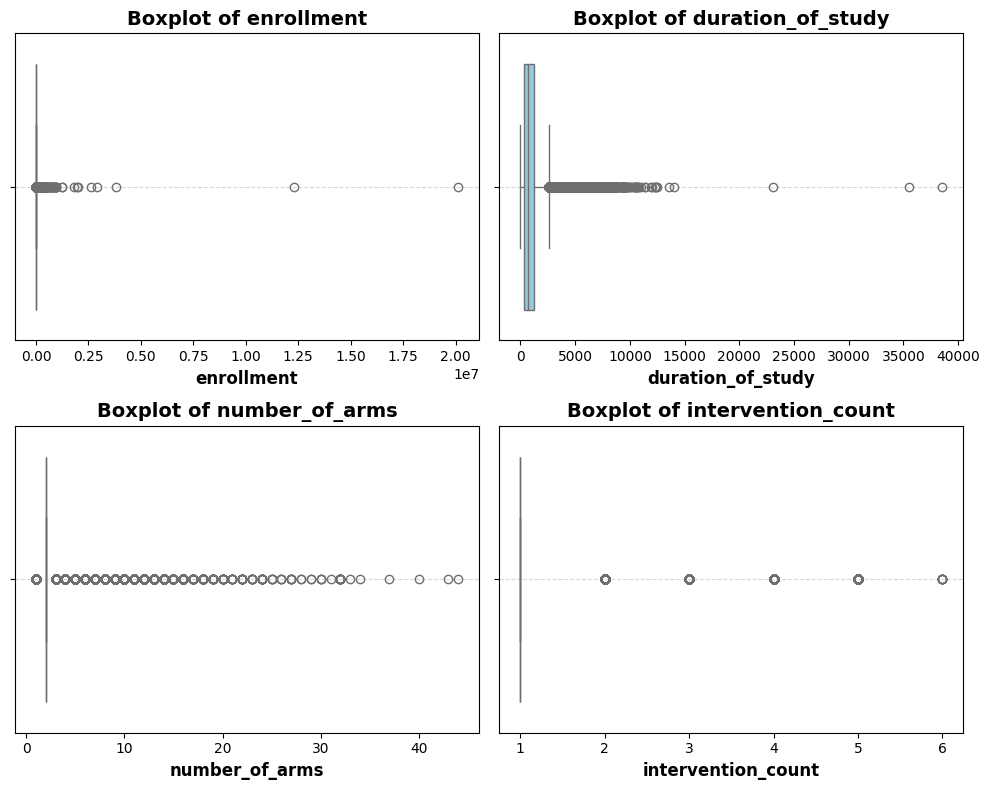

In [14]:
# 이상치 확인 
# Boxplot for numerical columns
numerical_cols = ['enrollment', 'duration_of_study', 'number_of_arms', 'intervention_count']

# Create 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x = df_EDA_1[col], color= 'skyblue', ax=axes[i])
    axes[i].set_title(f"Boxplot of {col}", fontsize = 14, fontweight = 'bold')
    axes[i].set_xlabel(col, fontsize = 12, fontweight = 'bold')
    axes[i].grid(True, axis = 'y', linestyle = '--', alpha = 0.5)
plt.tight_layout()
savefig('boxplot_num_cols.png')

In [15]:

# 연구기간 0보다 작은 데이터 필터링
df_EDA_1 = df_EDA_1[df_EDA_1['duration_of_study'] >= 0]
print(df_EDA_1.shape)

(278762, 80)


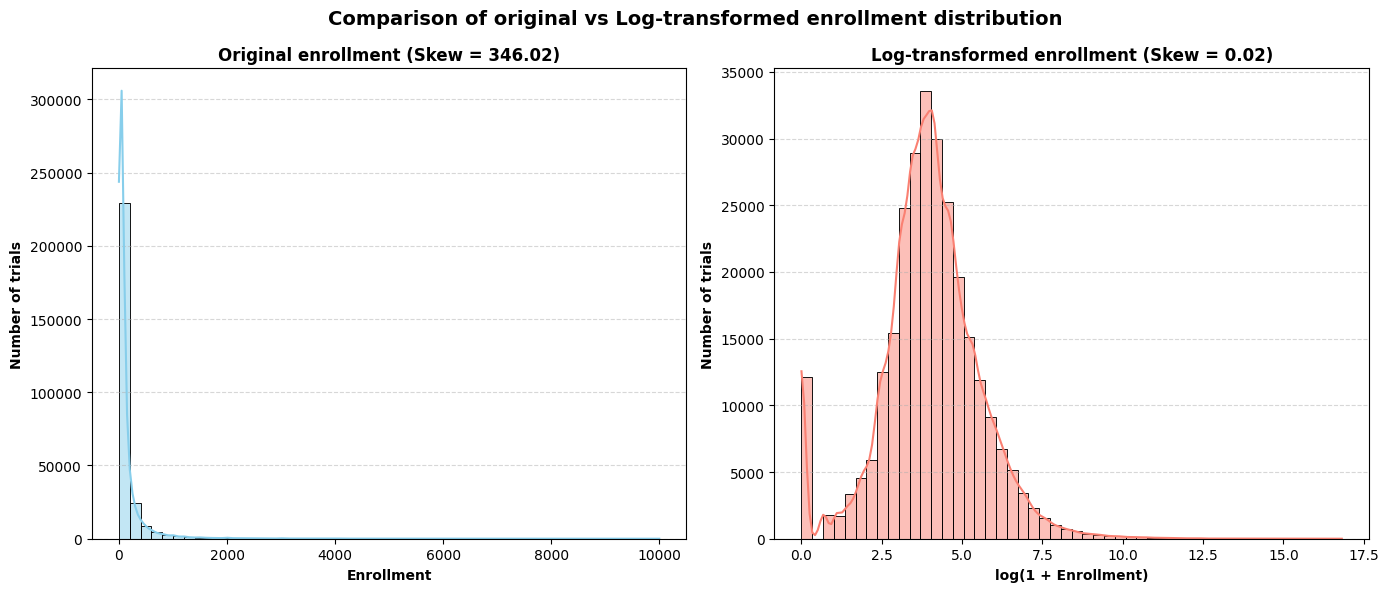

In [16]:
# Distribution of enrollment: original vs log-transformed 
# 참가자수 분포확인 : 원본 vs log변환 
# 로그변환 - 중요한 정보라 삭제하기 보다 데이터를 억누르는 시도 (극단적 이상치, 편차 클때 효과적 - 스케일 조정 )
# Apply log(1 + x) transformation to reduce skewness and handle zero values
# log1p - 참가자 수가 0명인 연구(feasibility study 타당성조사 등)에서 발생하는 로그 무한대 문제 방지하기 위함

df_EDA_1['log_enrollment'] = np.log1p(df_EDA_1['enrollment'])

# Plot original enrollment up to 10000 to keep histogram legible 
# 히스토그램 읽기 쉽도록 최대 10,000명까지 표기
subset = df_EDA_1[df_EDA_1['enrollment'] < 10000] 

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Raw Enrollment
sns.histplot(data = subset, x ='enrollment', kde = True, bins = 50, color = 'skyblue', edgecolor = 'black', ax = axes[0])
axes[0].set_title(f"Original enrollment (Skew = {df_EDA_1['enrollment'].skew():.2f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel('Enrollment', fontsize = 10, fontweight = 'bold')
axes[0].set_ylabel('Number of trials', fontsize = 10, fontweight = 'bold')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Log Enrollment
sns.histplot(data= df_EDA_1, x='log_enrollment',  kde = True, bins = 50, color = 'salmon', edgecolor = 'black', ax = axes[1])
axes[1].set_title(f"Log-transformed enrollment (Skew = {df_EDA_1['log_enrollment'].skew():.2f})", fontsize =12, fontweight ='bold')
axes[1].set_xlabel('log(1 + Enrollment)', fontsize =10, fontweight = 'bold')
axes[1].set_ylabel('Number of trials', fontsize =10, fontweight = 'bold')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Comparison of original vs Log-transformed enrollment distribution', fontsize=14, fontweight='bold')
savefig('enroll_dist_original_vs_log.png')

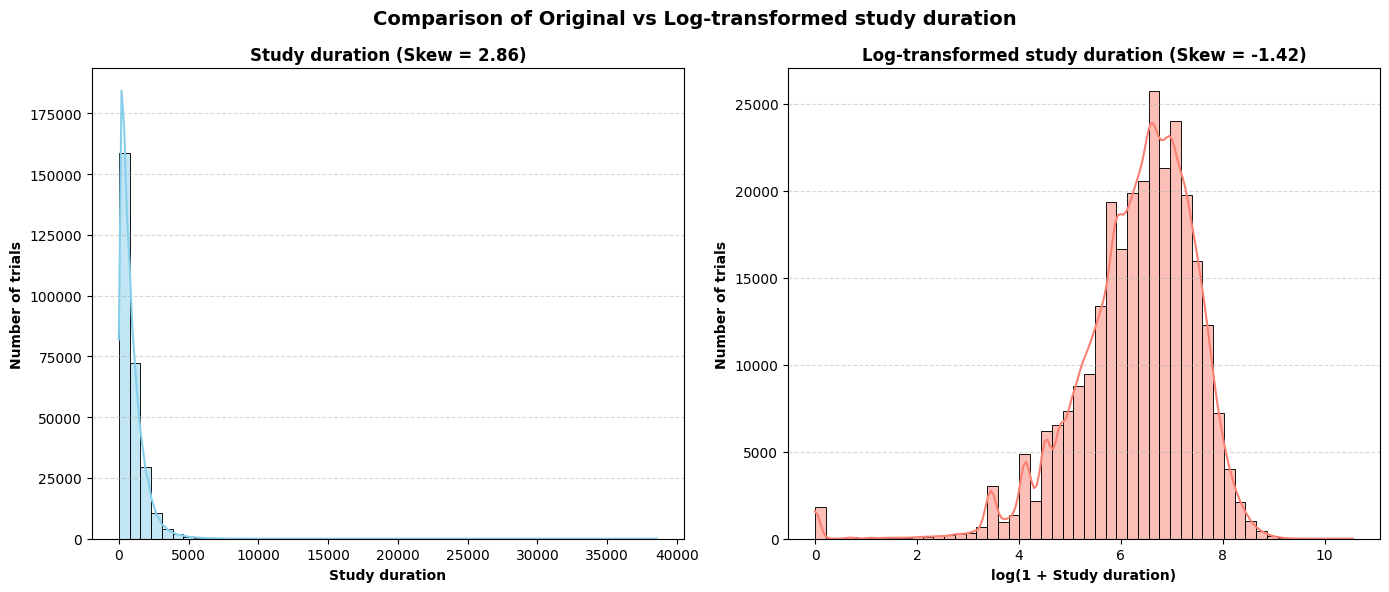

[SAVED] Comparison of original vs Log-transformed study duration


In [17]:
# study duration distributions : original vs log-transformed 
# 연구 기간 분포 확인 
# Apply log(1 + x) transformation to reduce skewness and handle zero values
df_EDA_1['log_duration'] = np.log1p(df_EDA_1['duration_of_study'])

# Create side-by-side subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot original duration
sns.histplot(df_EDA_1['duration_of_study'], kde = True, bins=50, color='skyblue',  edgecolor = 'black', ax=axes[0])
axes[0].set_title(f"Study duration (Skew = {df_EDA_1['duration_of_study'].skew():.2f})", fontsize=12, fontweight='bold')
axes[0].set_xlabel('Study duration', fontsize=10, fontweight = 'bold')
axes[0].set_ylabel('Number of trials', fontsize=10, fontweight = 'bold')
axes[0].grid(True, axis='y', linestyle='--', alpha=0.5)

# Plot log-transformed duration of study
sns.histplot(df_EDA_1['log_duration'], kde = True, bins=50, color='salmon',  edgecolor = 'black', ax=axes[1])
axes[1].set_title(f"Log-transformed study duration (Skew = {df_EDA_1['log_duration'].skew():.2f})", fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Study duration)', fontsize=10, fontweight = 'bold')
axes[1].set_ylabel('Number of trials', fontsize=10, fontweight = 'bold')
axes[1].grid(True, axis='y', linestyle='--', alpha=0.5)

# Super title
plt.suptitle('Comparison of Original vs Log-transformed study duration', fontsize=14, fontweight='bold')
savefig('duration_dist_original_vs_log.png')
print("[SAVED] Comparison of original vs Log-transformed study duration")

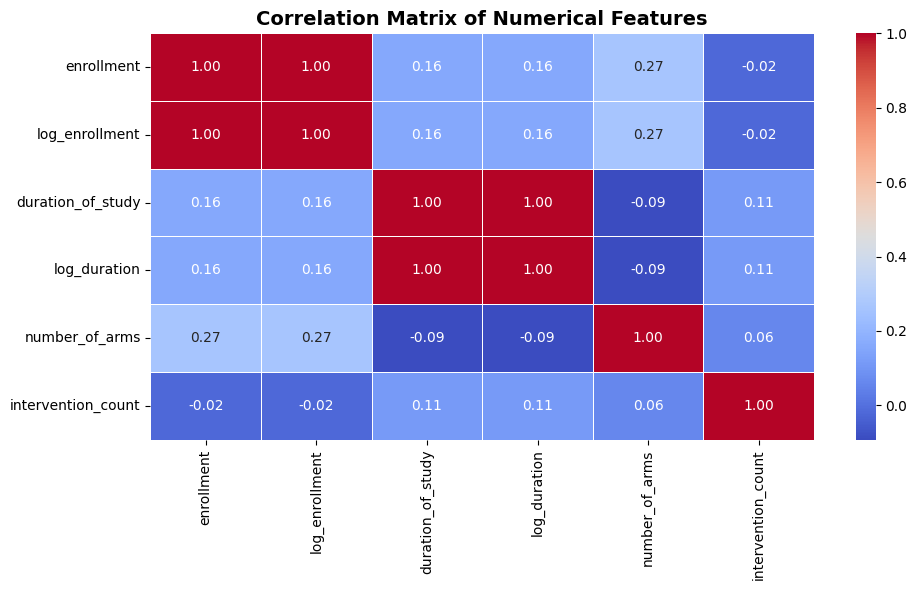

In [18]:
# 스피어만 상관관계 분석 (순위rank값 기준이라 이상치에 민감하지 않음 cf.피어슨 방식)
# Correlation Heatmap (numerical features)
numeric_cols = ['enrollment', 'log_enrollment','duration_of_study', 'log_duration', 'number_of_arms', 'intervention_count']

# Compute correlation among num features using Spearman (robust to skewness 왜곡에 강건함)
corr_matrix = df_EDA_1[numeric_cols].corr(method = 'spearman')

# Plot
plt.figure(figsize = (10, 6))
sns.heatmap(corr_matrix, annot = True, fmt = '.2f', cmap = 'coolwarm', linewidths = 0.5)
plt.title('Correlation Matrix of Numerical Features', fontsize = 14, fontweight = 'bold')
savefig("num_cols_correlation_heatmap.png")

In [23]:
# prefix로 구분되는 변수들의 빈도 확인 
# Function to plot categorical variables starting with a given prefix and print frequency tables
def plot_categorical_variables(df, prefix, exclude = None, title = None, palette = 'Set2', rotate_ticks = False):
    
    cols = [c for c in df.columns if c.startswith(prefix)]
    if exclude:
        cols = [c for c in cols if c not in exclude]
    
    counts = df[cols].apply(pd.to_numeric, errors = 'coerce').sum().sort_values(ascending = False).reset_index()
    counts.columns = ['category', 'count']
    counts['category'] = counts['category'].str.replace(prefix, '', regex = False).str.title()
    
    total = len(df)
    counts['percentage'] = (counts['count'] / total * 100).round(2)
    
    print(f"\nFrequency table for {prefix.replace('_', '')}:")
    display(counts)

    counts.to_csv(RESULTS_DIR / f"{prefix.replace('_', '')}_counts.csv")
    
    plt.figure(figsize = (10, 6))
    ax = sns.barplot(data = counts, x = 'category', y = 'count', hue = 'category', palette = palette, legend = False)
    if rotate_ticks:
        plt.xticks(rotation = 45, ha = 'right')
    plt.title(title, fontsize = 14, fontweight = 'bold')
    plt.xlabel(prefix.replace('_', '').title(), fontsize = 12, fontweight = 'bold')
    plt.ylabel('Number of trials', fontsize = 12, fontweight = 'bold')
    plt.grid(axis = 'y', linestyle = '--', alpha = 0.5)

    for p in ax.patches:
        count = p.get_height()
        percentage = count / total * 100
        ax.annotate(f'{percentage:.1f}%',
                    (p.get_x() + p.get_width()/2, count),
                    ha = 'center', va = 'bottom', fontsize = 10)
    savefig(f"{prefix.replace('_', '').title()}_dist.png")


Frequency table for phase:


,category,count,percentage
0,Unknown,133798,48.00
1,1,47402,17.00
2,2,43721,15.68
3,3,30057,10.78
4,4,23784,8.53


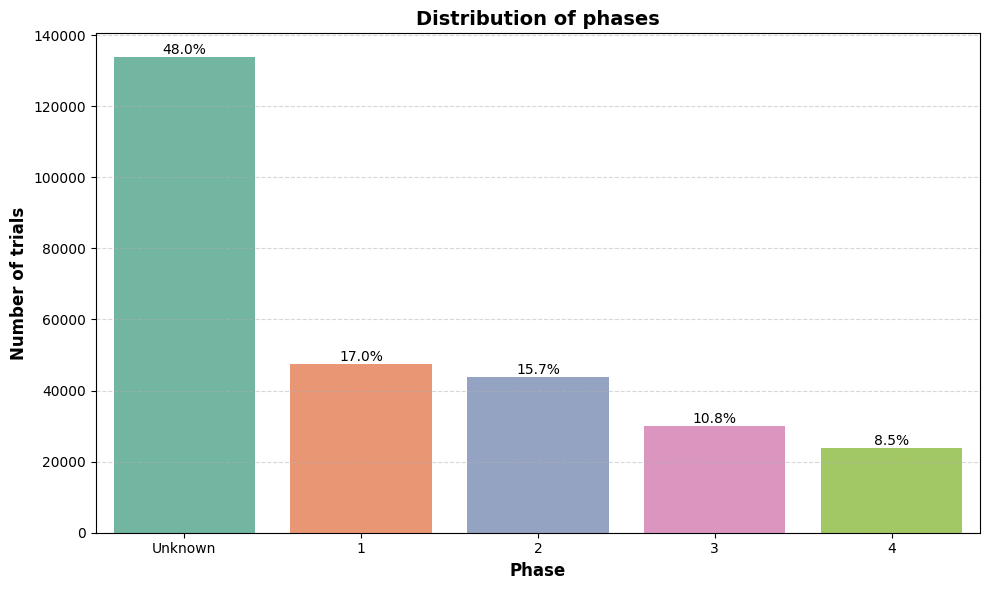

In [20]:
# 1. phase_ 변수
plot_categorical_variables(df_EDA_1, prefix = 'phase_', title = 'Distribution of phases')


Frequency table for intervention:


,category,count,percentage
0,Drug,129271,46.37
1,Other,54796,19.66
2,Device,36693,13.16
3,Behavioral,36255,13.01
4,Procedure,25501,9.15
5,Biological,17299,6.21
6,Dietary_Supplement,11545,4.14
7,Radiation,4435,1.59
8,Diagnostic_Test,3034,1.09
9,Combination_Product,1318,0.47


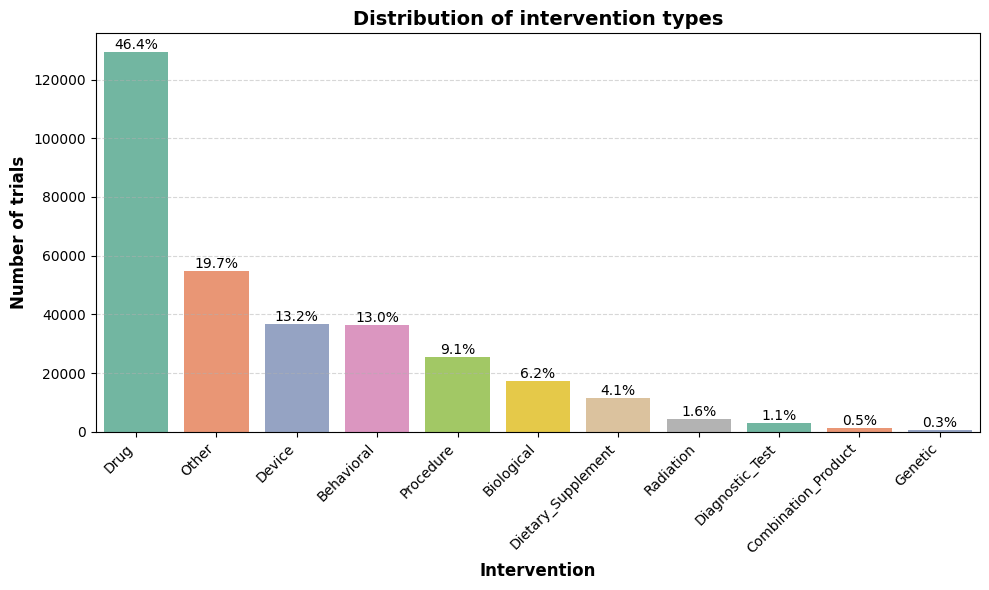

In [ ]:
# 2. intervention_ 변수 (약물 개입 정보)

plot_categorical_variables(df_EDA_1, prefix = 'intervention_', exclude = ['intervention_count'], title = 'Distribution of intervention types', rotate_ticks = True)

- Drug: 약물
- Other: 기타
- Device: 의료기기
- Behavioral: 행동
- Procedure: 처치/시술
- Biological: 생물학적제제
- Dietary_Supplement: 건강기능식품
- Radiation: 방사선
- Diagnostic_Test: 진단검사
- Combination_Product: 복합제품
- Genetic: 유전자'


Frequency table for condt:


,category,count,percentage
0,Others,105987.0,38.02
1,Cancers,46700.0,16.75
2,Mental_Disorders,37799.0,13.56
3,Cardiovascular_Diseases,22151.0,7.95
4,Endocrine/Metabolic_Disorders,20210.0,7.25
5,Infectious_Diseases,17025.0,6.11
6,Musculoskeletal_Disorders,12543.0,4.50
7,Gastrointestinal_Disorders,11996.0,4.30
8,Respiratory_Disorders,11970.0,4.29
9,Pain_Disorders,11363.0,4.08


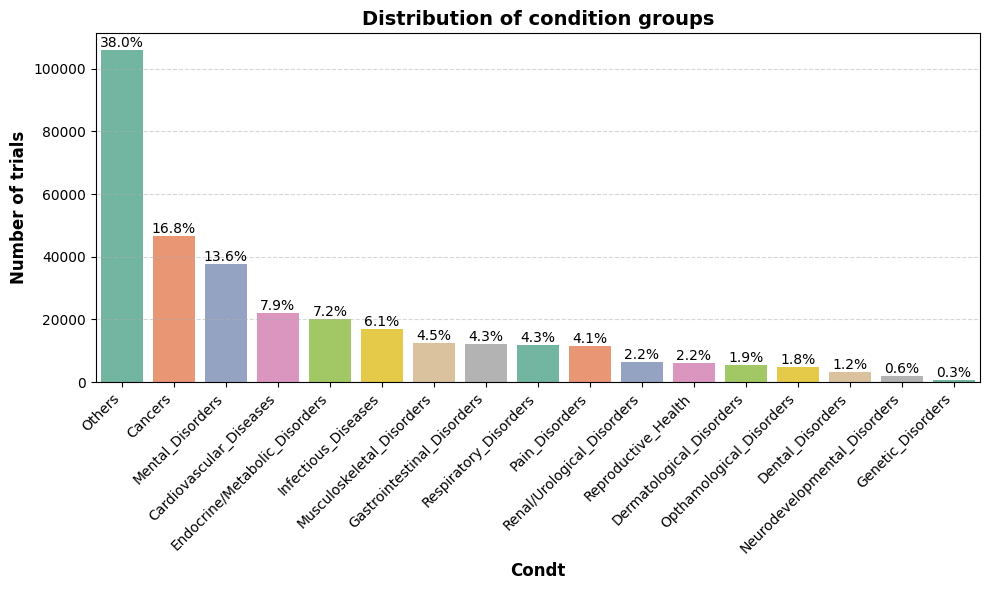

In [28]:
# 3. conditions 변수 (질환정보)
plot_categorical_variables(df_EDA_1, prefix = 'condt_', title = 'Distribution of condition groups', rotate_ticks = True)

- Others: 기타
- Cancers: 암/종앙
- Cardiovascular_Diseases: 심혈관 질환
- Endocrine/Metabolic_Disorders: 내분비/ 대사장애
- Mental_Disorders: 정신 질환
- Neurological_Disorders: 신경계 질환
- Infectious_Diseases: 감염성 질환
- Musculoskeletal_Disorders: 근골격계 질환
- Respiratory_Disorders: 호흡기 질환
- Gastrointestinal_Disorders: 위장관 질환
- Pain_Disorders: 통증 질환
- Renal/Urological_Disorders: 신장/ 비뇨기 질환
- Reproductive_Health: 생식 건강
- Dermatological_Disorders: 피부과 질환
- Opthamological_Disorders: 안과 질환
- Dental_Disorders: 치과 질환
- Genetic_Disorders: 유전 질환



Frequency table for allocation:


,category,count,percentage
0,Randomized,181292.0,65.03
1,Non_Randomized,87640.0,31.44
2,Unknown,3908.0,1.40


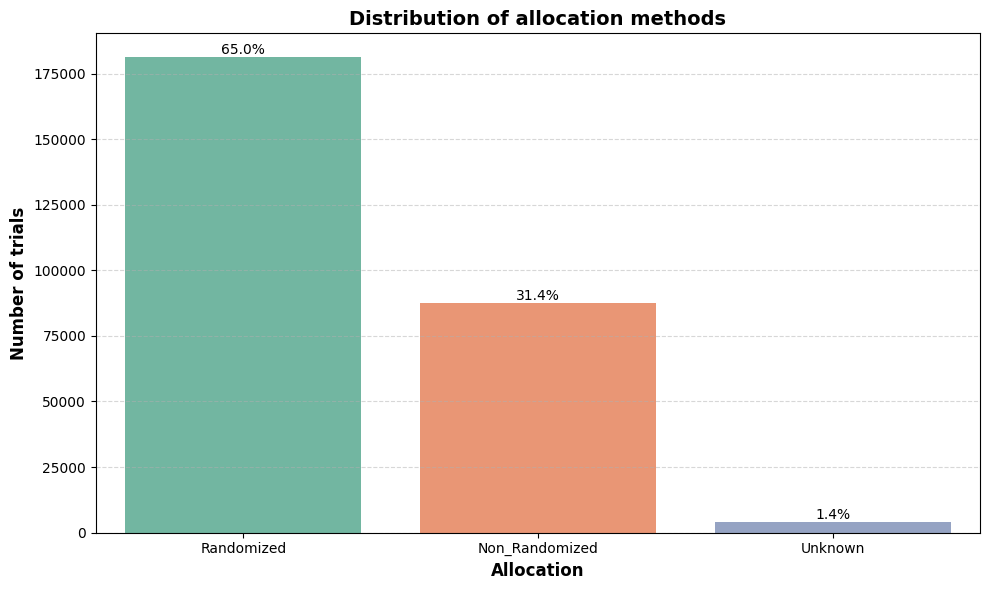

In [ ]:
# 4. study designs의 allocation 변수 (배정 방법)
plot_categorical_variables(df_EDA_1, prefix = 'allocation_', title = 'Distribution of allocation methods')

- randomized: 무작위 배정
- non_ramdomized: 비무작위 배정


Frequency table for model:


,category,count,percentage
0,Parallel,164296.0,58.94
1,Single_Group,68466.0,24.56
2,Crossover,26255.0,9.42
3,Sequential,6555.0,2.35
4,Factorial,4003.0,1.44
5,Unknown,3265.0,1.17


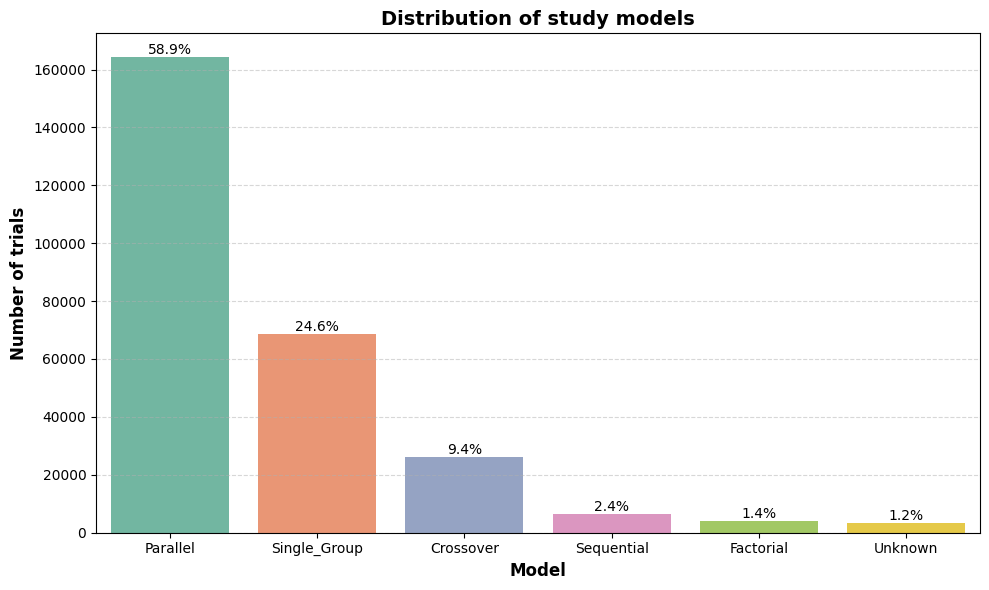

In [ ]:
# 5. study designs의 models 변수 (설계 방식)
plot_categorical_variables(df_EDA_1, prefix = 'model_', title = 'Distribution of study models')

- parallel: 평행 설계 (약물군vs대조군)
- single group: 단일군 설계 (대조군 없음)
- crossover: 교차 설계 (모든 환자가 두가지 치료 순차적으로 모두 경험)
- sequential: 순차 설계 (중간 데이터 바탕으로 피험자수나 진행여부 조정하는 단계적으로 진행하는 방식)
- factorial: 요인 설계 (두가지 이상의 치료법 조합 예: A약, B약, A+B약)
- unknown: 알수 없음 (설계 방식이 등록되지 않았거나 불분명한 경우)


Frequency table for purpose:


,category,count,percentage
0,Treatment,169955.0,60.97
1,Prevention,29963.0,10.75
2,Research,22974.0,8.24
3,Other,16506.0,5.92
4,Supportive_Care,15122.0,5.42
5,Diagnostic,13379.0,4.80
6,Unknown,4941.0,1.77


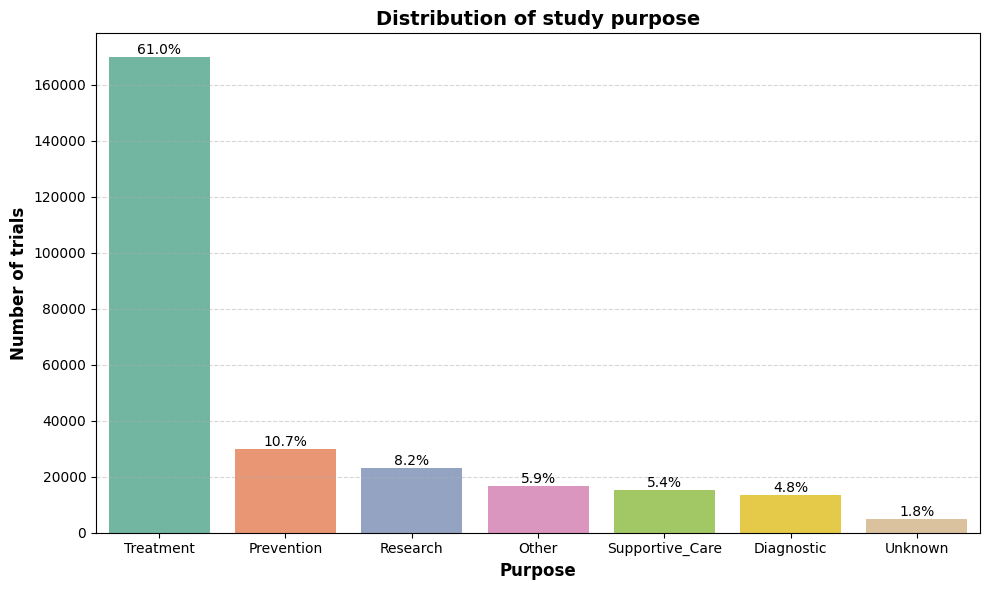

In [ ]:
# 6.study designs의 purpose 변수 (임상시험 목적)
plot_categorical_variables(df_EDA_1, prefix = 'purpose_', title = 'Distribution of study purpose')

- treatment: 치료
- prevention: 예방 (질환이 없는 사람을 대상으로 질병이 발생하지 않도록 막거나 재발 방지 연구)
- research: 연구/기초과학 (질병의 기전이나 원인 밝히기 위한 학술적 목적)
- other: 기타 ( 위 범주에 속하지 않는 다양한 목적)
- suppoortive_care: 지지요법 (질병 자체를 치료하기보다 통증완화, 부작용 관리등 환자의 삶의질을 높이기 위한 보조적인 치료 연구 )
- diagnostic: 진단 (새로운 검사법이나 도구를 통해 질환을 더 정확하고 빠르게 찾아내기 위한 연구)
- unknown: 알수없음 (목적이 명시되지 않았거나 확인되지 않은 경우)


Frequency table for masking:


,category,count,percentage
0,Unknown,149092.0,53.48
1,Single,39341.0,14.11
2,Double,38541.0,13.83
3,Quadruple,26862.0,9.64
4,Triple,19004.0,6.82


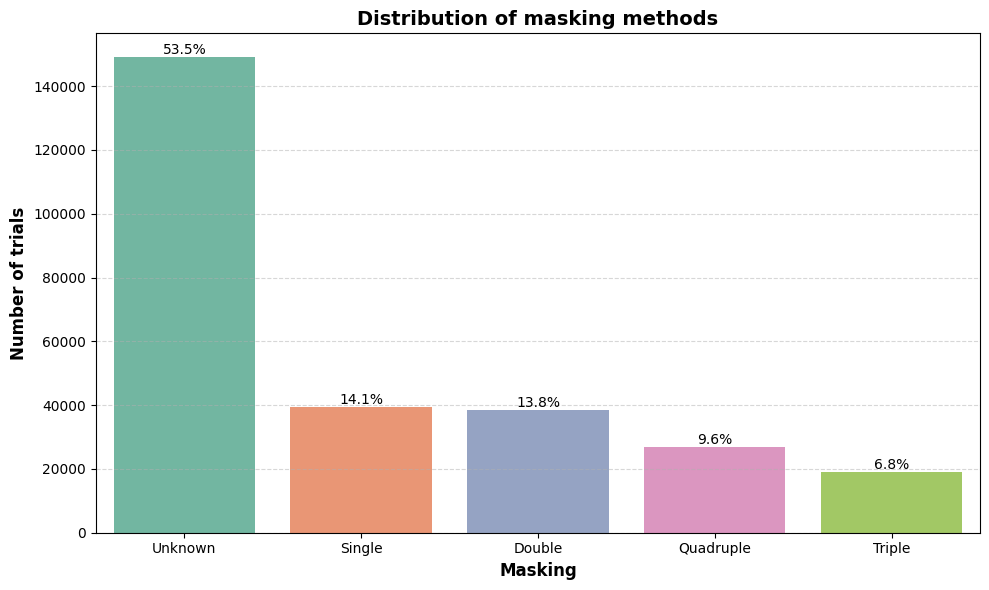

In [ ]:
# 7. study designs의 masking 변수 (눈가림 수준 - 연구의 객관성을 높이기 위해 누가 어떤 처치를 받는지 모르게 하는 장치)
plot_categorical_variables(df_EDA_1, prefix = 'masking_', title = 'Distribution of masking methods')

- unknown: 알수없음 (눈가림 방식 등록되지 않았거나 불분명)
- single: 단일 눈가림 (환자만 자신이 어떤약을 받는지 모름)
- double: 이중 눈가림 (환자와 의사 모두 모름. 가장 일반적 표준방식)
- quadruple: 사중 눈가림 (환자, 의사, 데이터분석가, 결과 평가자 모두 모르게 하여 객관성 극대화)
- triple: 삼중 눈가림 (환자, 의사, 데이터 분석가까지 모름)


Frequency table for sponsor:


,category,count,percentage
0,Other,189730,68.06
1,Industry,102468,36.76
2,Goverment,40760,14.62
3,Unknown,11921,4.28


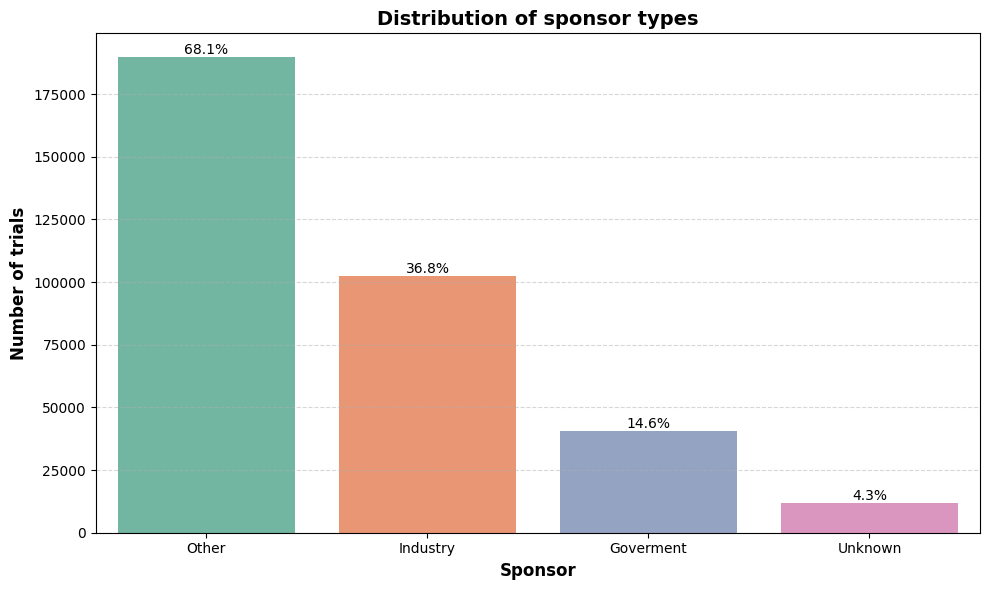

In [ ]:
# 8. sponsor type 변수 (후원자 유형)
plot_categorical_variables(df_EDA_1, prefix = 'sponsor_', title = 'Distribution of sponsor types')

- other: 주로 대학, 병원, 비영리단체 주도하는 학술적 목적
- industry: 산업계 (제약사, 의료기기 업체)
- goverment: 정부기관 (국가 예산으로 지원하는 공익적 성격의 연구)
- unknown: 알수없음 (후원기관 정보 없거나 명확하지 않은 경우)


Frequency table for role:


,category,count,percentage
0,Lead,278762,100.0
1,Collaborator,94208,33.8


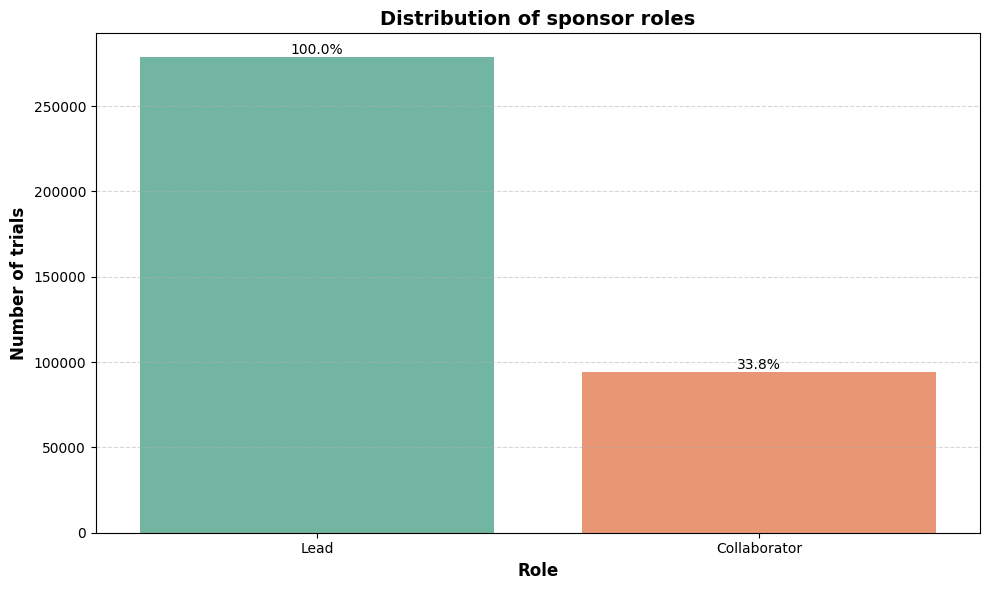

In [ ]:
# 9. sponsor roles 변수 (수행 기관의 성격)
plot_categorical_variables(df_EDA_1, prefix = 'role_', title = 'Distribution of sponsor roles')

- lead: 주관기관/연구책임 (연구를 전체적으로 기획하고 최종 책임지는 기관)
- collaborator: 협력기관/공동참여 (주관기관과 함께 연구에 참여하여 환자모집, 데이터수직, 자금지원 등을 분담)


Frequency table for elig:


,category,count,percentage
0,Gender_All,237778,85.30
1,Age_Adult,174522,62.61
2,Age_Mixed,75585,27.11
3,Gender_Female,26865,9.64
4,Age_Child,17915,6.43
5,Gender_Male,14119,5.06
6,Age_Unknown,9295,3.33
7,Age_Senior,1445,0.52


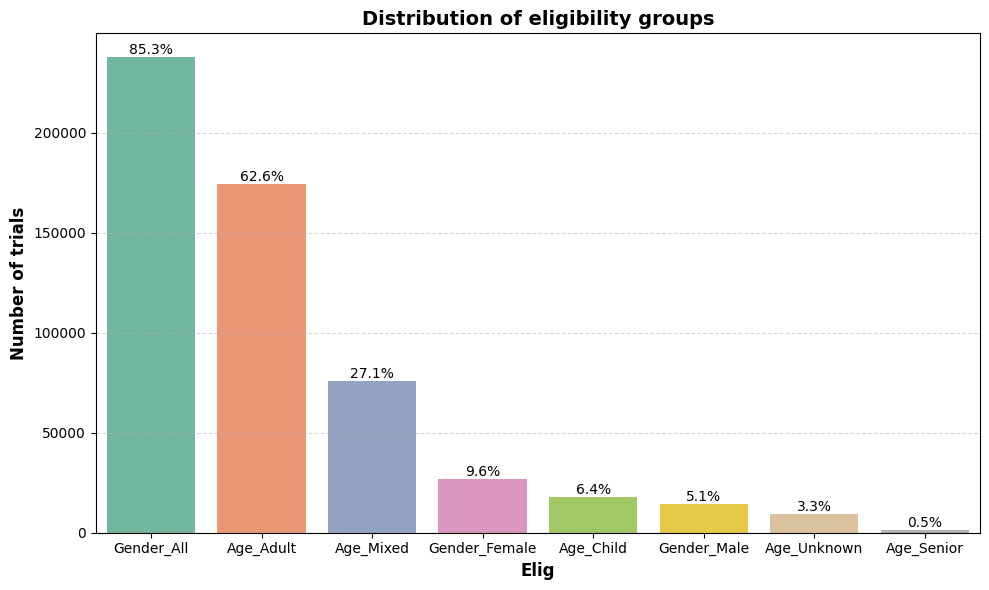

In [ ]:
# 10. eligibilites 변수 (참여 대상자 성별과 연령대 분류)
plot_categorical_variables(df_EDA_1, prefix = 'elig_', title = 'Distribution of eligibility groups')

In [36]:
# Export dataset for EDA Part 2
df_EDA_1.to_csv(DATA_PROCESSED / "df_EDA_1.csv", index=False)